# CT-JEPA Data Preprocessing

Nodule-centred preprocessing pipeline for LIDC-IDRI using XML annotations.

In [1]:
import sys
from pathlib import Path

# Set project root
PROJECT_ROOT = Path("..").resolve()
sys.path.append(str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: /home/sreethanu/Downloads/lung_cancer_vljepa


In [2]:
import gc
import os
import re
import shutil
import xml.etree.ElementTree as ET
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pydicom
from tqdm import tqdm

from src.utils.config import load_config
from src.utils.seed import set_global_seed
from src.preprocessing.preprocess import CTPreprocessor

## Load Config and Paths

In [3]:
CONFIG_PATH = PROJECT_ROOT / "configs" / "jepa_config.yaml"
config = load_config(CONFIG_PATH)

set_global_seed(
    seed=config["project"]["seed"],
    deterministic=config["project"]["deterministic"],
)

RAW_DICOM_DIR = PROJECT_ROOT / config["data"]["raw_dir"]
PROCESSED_DIR = PROJECT_ROOT / config["data"]["processed_dir"]
PATCH_ROOT    = PROCESSED_DIR / "patches"
METADATA_DIR  = PROCESSED_DIR / "metadata"
XML_ROOT      = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "annotations"
    / "tcia-lidc-xml"
)

print("Raw DICOM Dir:", RAW_DICOM_DIR)
print("Processed Dir:", PROCESSED_DIR)
print("XML Root:     ", XML_ROOT)
print("XML exists:   ", XML_ROOT.exists())

Setting global seed: 42
Enabling deterministic mode (may reduce performance)
Reproducibility configured successfully.
Raw DICOM Dir: /home/sreethanu/Downloads/lung_cancer_vljepa/data/raw/LIDC-IDRI
Processed Dir: /home/sreethanu/Downloads/lung_cancer_vljepa/data/processed
XML Root:      /home/sreethanu/Downloads/lung_cancer_vljepa/data/raw/annotations/tcia-lidc-xml
XML exists:    True


In [4]:
if PROCESSED_DIR.exists():
    shutil.rmtree(PROCESSED_DIR)
    print("Deleted old processed directory.")

PATCH_ROOT.mkdir(parents=True, exist_ok=True)
METADATA_DIR.mkdir(parents=True, exist_ok=True)
print("Created fresh output directories.")

Deleted old processed directory.
Created fresh output directories.


## Build Series ↔ Patient Mapping

In [5]:
series_to_patient = {}
patient_to_series = defaultdict(list)

for series_folder in tqdm(RAW_DICOM_DIR.iterdir(), desc="Mapping Series to Patient"):
    if not series_folder.is_dir():
        continue

    dcm_files = list(series_folder.glob("*.dcm"))
    if len(dcm_files) == 0:
        continue

    try:
        ds = pydicom.dcmread(dcm_files[0], stop_before_pixels=True)
        patient_id = str(ds.PatientID).strip()
        series_uid = series_folder.name
        series_to_patient[series_uid] = patient_id
        patient_to_series[patient_id].append(series_uid)
    except Exception:
        continue

print("Mapped series:  ", len(series_to_patient))
print("Mapped patients:", len(patient_to_series))

Mapping Series to Patient: 1309it [00:00, 2642.22it/s]

Mapped series:   1308
Mapped patients: 1010


## Parse XML Nodules and Build Labels

In [6]:
from pathlib import Path
import xml.etree.ElementTree as ET
import re
from collections import defaultdict
from tqdm import tqdm
import numpy as np

# ============================================================
# XML FILES
# ============================================================

xml_files = sorted(XML_ROOT.rglob("*.xml"))
print("Total XML files found:", len(xml_files))

# Quick probe — print first 3 paths and their extracted patient IDs
# to verify the path layout before running the full pipeline.
print("\nPath layout probe (first 3 XML files):")
for f in xml_files[:3]:
    print(" ", f)


# ============================================================
# PATIENT ID EXTRACTION  (Bug A fix)
# ============================================================
#
# Original version only searched the file *path* for LIDC-IDRI-XXXX.
# TCIA downloads often store XML files inside folders named by series UID
# (e.g. 1.3.6.1.4.1.14519.../annotation.xml), so the pattern never matched
# and every file was silently skipped, producing 0 patients.
#
# Fix: try the path first (fast), then fall back to reading the XML itself
# and extracting the patient ID from the StudyInstanceUID or a dedicated tag.

def extract_patient_id_from_xml(xml_file: Path) -> str | None:
    # --- Strategy 1: LIDC-IDRI-XXXX pattern anywhere in the path (fast) ---
    match = re.search(r"LIDC-IDRI-(\d{4})", str(xml_file))
    if match:
        return f"LIDC-IDRI-{match.group(1)}"

    # --- Strategy 2: parse the XML and look for explicit tags ---
    try:
        tree = ET.parse(xml_file)
        root = tree.getroot()

        for elem in root.iter():
            tag = elem.tag.split("}")[-1].lower()

            # Some LIDC XML files carry a PatientID element directly
            if tag == "patientid" and elem.text:
                pid = elem.text.strip()
                if re.match(r"LIDC-IDRI-\d{4}", pid):
                    return pid
                # Bare 4-digit number (e.g. "0001")
                if re.match(r"\d{4}", pid):
                    return f"LIDC-IDRI-{pid}"

            # StudyInstanceUID encodes the patient number in LIDC
            # e.g. 1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288633453246975630178
            # The patient number is NOT reliably extractable from the UID itself,
            # so we only use this as a last resort via the DICOM mapping.
            if tag == "studyinstanceuid" and elem.text:
                uid = elem.text.strip()
                # Check whether this UID is already known from the DICOM scan
                # (series_to_patient was built in the previous cell)
                if uid in series_to_patient:
                    return series_to_patient[uid]

            if tag == "seriesinstanceuid" and elem.text:
                uid = elem.text.strip()
                if uid in series_to_patient:
                    return series_to_patient[uid]

    except Exception:
        pass

    return None


# ============================================================
# NODULE EXTRACTION  (Bug B fix)
# ============================================================
#
# Original version only extracted centroid from <edgeMap> elements.
# In LIDC-IDRI, some radiologists annotate a nodule with a single
# centre-point <locus> instead of a full contour — especially for
# 1-3 mm nodules or secondary nodule marks. When only <locus> is
# present the edgeMap loop produced coords=[], centroid stayed None,
# and the aggregation filter discarded the nodule.
#
# Fix: collect <locus> points as a fallback inside the same roi loop.
# edgeMap contour centroids are always preferred; locus is used only
# when no edgeMap points were found for a given roi slice.

def extract_nodules_from_xml(xml_path: str) -> dict:
    nodules = {}

    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except Exception:
        return nodules

    # Extract Series UID once per XML file (all nodules in this file share it)
    series_uid = None
    for elem in root.iter():
        tag = elem.tag.split("}")[-1]
        if tag.lower() == "seriesinstanceuid" and elem.text:
            series_uid = elem.text.strip()
            break

    for session in root.iter():
        if session.tag.split("}")[-1] != "readingSession":
            continue

        for nodule in session:
            tag = nodule.tag.split("}")[-1]

            if tag != "unblindedReadNodule":
                continue

            nodule_id = None
            scores    = []
            centroid  = None

            # --- Nodule ID ---
            for child in nodule:
                if child.tag.split("}")[-1] == "noduleID" and child.text:
                    nodule_id = child.text.strip()

            if nodule_id is None:
                continue

            # --- Malignancy score ---
            for child in nodule:
                if child.tag.split("}")[-1] == "characteristics":
                    for c in child:
                        if "malignancy" in c.tag.lower():
                            try:
                                scores.append(float(c.text))
                            except Exception:
                                pass

            # --- Centroid computation ---
            # imageZposition  -> world mm  (z)
            # xCoord, yCoord  -> pixel indices in DICOM image — NOT world mm
            #                    (conversion to world mm happens in preprocess_patient)
            coords = []  # one (mean_x_px, mean_y_px, z_world_mm) per roi slice

            for roi in nodule.iter():
                if roi.tag.split("}")[-1] != "roi":
                    continue

                z            = None
                xs, ys       = [], []  # edgeMap contour points
                locus_points = []      # fallback: single centre-point annotations

                for elem in roi:
                    t = elem.tag.split("}")[-1]

                    if t == "imageZposition":
                        try:
                            z = float(elem.text)
                        except Exception:
                            pass

                    elif t == "edgeMap":
                        # Each <edgeMap> child holds one contour point.
                        x = y = None
                        for pt in elem:
                            pt_tag = pt.tag.split("}")[-1]
                            if pt_tag == "xCoord":
                                try:
                                    x = float(pt.text)
                                except Exception:
                                    pass
                            elif pt_tag == "yCoord":
                                try:
                                    y = float(pt.text)
                                except Exception:
                                    pass
                        if x is not None and y is not None:
                            xs.append(x)
                            ys.append(y)

                    elif t == "locus":
                        # <locus> is a single centre-point used for small nodules
                        # or radiologists who mark a point instead of drawing a contour.
                        # Only used if no edgeMap points exist for this roi slice.
                        lx = ly = None
                        for pt in elem:
                            pt_tag = pt.tag.split("}")[-1]
                            if pt_tag == "xCoord":
                                try:
                                    lx = float(pt.text)
                                except Exception:
                                    pass
                            elif pt_tag == "yCoord":
                                try:
                                    ly = float(pt.text)
                                except Exception:
                                    pass
                        if lx is not None and ly is not None:
                            locus_points.append((lx, ly))

                # Prefer edgeMap centroid; fall back to locus if unavailable.
                effective_xs = xs if xs else [p[0] for p in locus_points]
                effective_ys = ys if ys else [p[1] for p in locus_points]

                if z is not None and len(effective_xs) > 0:
                    coords.append((
                        float(np.mean(effective_xs)),
                        float(np.mean(effective_ys)),
                        z,
                    ))

            if len(coords) > 0:
                coords_arr = np.array(coords, dtype=np.float64)
                # Stored as (z_world_mm, y_pixel_idx, x_pixel_idx)
                # z  — world mm from imageZposition
                # y,x — pixel indices from edgeMap/locus; converted to world in preprocess_patient
                centroid = (
                    float(np.mean(coords_arr[:, 2])),  # z world mm
                    float(np.mean(coords_arr[:, 1])),  # y pixel index
                    float(np.mean(coords_arr[:, 0])),  # x pixel index
                )

            nodules[nodule_id] = {
                "scores":     scores,
                "centroid":   centroid,
                "series_uid": series_uid,
            }

    return nodules


# ============================================================
# MAIN PIPELINE  (diagnostic counters added)
# ============================================================

patient_nodule_index = defaultdict(dict)
xml_errors = 0

# Diagnostic counters — used in the next cell to pinpoint which
# bug (A / B / C) was active before the fixes were applied.
diag = {
    "xml_no_patient_id":     0,  # Bug A: path regex missed, XML fallback also failed
    "xml_no_nodules":        0,  # XML parsed but contained no unblindedReadNodule entries
    "nodules_seen":          0,  # total unblindedReadNodule entries across all files
    "nodules_with_scores":   0,  # had at least one malignancy score
    "nodules_with_centroid": 0,  # had at least one roi with spatial coords
    "nodules_both":          0,  # had both — these survive the aggregation filter
}

for xml_file in tqdm(xml_files, desc="Parsing XML annotations"):
    try:
        patient_id = extract_patient_id_from_xml(xml_file)
        if patient_id is None:
            diag["xml_no_patient_id"] += 1
            continue

        nodules_by_id = extract_nodules_from_xml(str(xml_file))
        if len(nodules_by_id) == 0:
            diag["xml_no_nodules"] += 1
            continue

        for nodule_id, data in nodules_by_id.items():
            scores   = data.get("scores", [])
            centroid = data.get("centroid")

            # --- Diagnostics ---
            diag["nodules_seen"] += 1
            has_scores   = len(scores) > 0
            has_centroid = centroid is not None
            if has_scores:              diag["nodules_with_scores"] += 1
            if has_centroid:            diag["nodules_with_centroid"] += 1
            if has_scores and has_centroid: diag["nodules_both"] += 1

            if nodule_id not in patient_nodule_index[patient_id]:
                patient_nodule_index[patient_id][nodule_id] = {
                    "scores":           [],
                    "centroid_samples": [],
                    "series_uid":       None,
                }

            patient_nodule_index[patient_id][nodule_id]["scores"].extend(scores)

            # Never append (0, 0, 0) as a fallback.
            # A missing centroid means the radiologist drew no contour and no locus
            # (can happen for sub-mm or excluded findings). Inserting (0,0,0) shifts
            # the mean centroid toward the image corner, placing patches in background
            # air. Just skip it — the aggregation filter below handles nodules that
            # end up with zero centroid samples.
            if centroid is not None:
                patient_nodule_index[patient_id][nodule_id]["centroid_samples"].append(centroid)

            # Always update series_uid if the current value is still None.
            if (
                patient_nodule_index[patient_id][nodule_id]["series_uid"] is None
                and data.get("series_uid") is not None
            ):
                patient_nodule_index[patient_id][nodule_id]["series_uid"] = data["series_uid"]

    except Exception:
        xml_errors += 1


# ============================================================
# FINAL AGGREGATION
# ============================================================

patient_to_nodule_annotations = defaultdict(list)

for patient_id, nodules in patient_nodule_index.items():
    for nodule_id, data in nodules.items():

        scores           = [float(s) for s in data.get("scores", [])]
        centroid_samples = data.get("centroid_samples", [])

        # Drop nodules that have no malignancy label OR no spatial anchor.
        # This filter is intentionally strict:
        #   - no scores  -> can't label the patch for training
        #   - no centroid -> can't extract a meaningful patch
        # After the Bug A + B fixes above, valid annotated nodules will have both.
        if len(scores) == 0 or len(centroid_samples) == 0:
            continue

        avg_score = float(np.mean(scores))

        centroid_arr = np.array(centroid_samples, dtype=np.float32)
        centroid = (
            float(np.mean(centroid_arr[:, 0])),  # z world mm
            float(np.mean(centroid_arr[:, 1])),  # y pixel index
            float(np.mean(centroid_arr[:, 2])),  # x pixel index
        )

        if avg_score >= 4.0:
            label = 1
        elif avg_score <= 2.0:
            label = 0
        else:
            label = None  # ambiguous — excluded from supervised training

        patient_to_nodule_annotations[patient_id].append({
            "nodule_id":  str(nodule_id),
            "scores":     scores,
            "avg_score":  avg_score,
            "label":      label,
            "series_uid": data.get("series_uid"),
            "centroid":   centroid,
        })


print("\n========== XML PARSE SUMMARY ==========")
print(f"Total XML files:                {len(xml_files)}")
print(f"XML files with parser errors:   {xml_errors}")
print(f"Skipped (no patient ID):        {diag['xml_no_patient_id']}")
print(f"Skipped (no nodules in XML):    {diag['xml_no_nodules']}")
print(f"\nNodule entries seen:            {diag['nodules_seen']}")
print(f"  with malignancy scores:       {diag['nodules_with_scores']}")
print(f"  with centroid:                {diag['nodules_with_centroid']}")
print(f"  with both (survive filter):   {diag['nodules_both']}")
print(f"\nPatients with nodule annotations: {len(patient_to_nodule_annotations)}")
print("========================================")

Total XML files found: 1318

Path layout probe (first 3 XML files):
  /home/sreethanu/Downloads/lung_cancer_vljepa/data/raw/annotations/tcia-lidc-xml/157/158.xml
  /home/sreethanu/Downloads/lung_cancer_vljepa/data/raw/annotations/tcia-lidc-xml/157/159.xml
  /home/sreethanu/Downloads/lung_cancer_vljepa/data/raw/annotations/tcia-lidc-xml/157/160.xml


Parsing XML annotations: 100%|█████████████| 1318/1318 [00:12<00:00, 102.93it/s]



========== XML PARSE SUMMARY ==========
Total XML files:                1318
XML files with parser errors:   0
Skipped (no patient ID):        0
Skipped (no nodules in XML):    303

Nodule entries seen:            20356
  with malignancy scores:       7030
  with centroid:                20356
  with both (survive filter):   7030

Patients with nodule annotations: 875


In [7]:
print(len(patient_to_nodule_annotations))

875


In [8]:
total_nodules = sum(len(v) for v in patient_to_nodule_annotations.values())
print(total_nodules)

6851


In [9]:
with_centroid = 0
without_centroid = 0

for nodules in patient_to_nodule_annotations.values():
    for n in nodules:
        if n["centroid"] is not None:
            with_centroid += 1
        else:
            without_centroid += 1

print(with_centroid, without_centroid)

6851 0


In [10]:
print(len(series_to_patient))

1308


In [11]:
labels = []

for nodules in patient_to_nodule_annotations.values():
    for n in nodules:
        if n["label"] is not None:
            labels.append(n["label"])

from collections import Counter
print(Counter(labels))

Counter({0: 2599, 1: 1651})


In [12]:
n = list(patient_to_nodule_annotations.values())[0][0]
print(n)

{'nodule_id': '3', 'scores': [3.0], 'avg_score': 3.0, 'label': None, 'series_uid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102183795724852353824', 'centroid': (1543.0, 169.1132049560547, 360.9681091308594)}


In [13]:
# ============================================================
# BUG DIAGNOSIS REPORT
# ============================================================
#
# Read the counters above to identify which bug was the root cause:
#
#  'xml_no_patient_id' == len(xml_files)
#      -> Bug A was the sole cause. The path regex never matched because
#         your XML files are stored in UID-named folders. The fallback
#         fix in extract_patient_id_from_xml() resolves this.
#
#  'nodules_with_centroid' == 0  AND  'nodules_with_scores' > 0
#      -> Bug B was the cause. edgeMap tags were not being found (possibly
#         locus-only annotations). The locus fallback fix resolves this.
#
#  'nodules_both' > 0  AND  len(patient_to_nodule_annotations) == 0
#      -> Something is broken in the aggregation loop itself (unlikely
#         after A+B are fixed). File a separate bug report.

if diag["xml_no_patient_id"] == len(xml_files):
    print("[DIAGNOSIS] Bug A detected: patient ID could not be extracted from ANY file.")
    print("            Check that extract_patient_id_from_xml() fallback logic covers")
    print("            your XML folder structure.")
elif diag["nodules_with_centroid"] == 0 and diag["nodules_with_scores"] > 0:
    print("[DIAGNOSIS] Bug B detected: scores found but zero centroids.")
    print("            edgeMap/locus parsing produced no coordinates.")
elif len(patient_to_nodule_annotations) > 0:
    print("[OK] Pipeline healthy. Proceeding with",
          len(patient_to_nodule_annotations), "patients.")
else:
    print("[DIAGNOSIS] All three counters are non-zero but patients==0.")
    print("            Inspect the aggregation loop for unexpected exceptions.")

[OK] Pipeline healthy. Proceeding with 875 patients.


In [14]:
# Validate series UID extraction — should be close to patient count
uids = set()

for patient_id, nodules in patient_to_nodule_annotations.items():
    for n in nodules:
        if n.get("series_uid"):
            uids.add(n["series_uid"])

print("Unique series UIDs:", len(uids))

# Safe merge: extend series_to_patient with any XML-derived UIDs not already present.
# Never overwrites the authoritative DICOM-derived mapping built in the previous cell.
for patient_id, nodules in patient_to_nodule_annotations.items():
    for n in nodules:
        s_uid = n.get("series_uid")
        if s_uid and s_uid not in series_to_patient:
            series_to_patient[s_uid] = patient_id

print("Total series_to_patient entries:", len(series_to_patient))

Unique series UIDs: 883
Total series_to_patient entries: 1308


In [15]:
# Sanity check — inspect a couple of patients
print("Patients parsed:", len(patient_to_nodule_annotations))

sample = list(patient_to_nodule_annotations.items())[:2]

for patient_id, nodules in sample:
    print("Patient:", patient_id)
    print("Nodules:", len(nodules))
    print(nodules[:1])

Patients parsed: 875
Patient: LIDC-IDRI-0078
Nodules: 13
[{'nodule_id': '3', 'scores': [3.0], 'avg_score': 3.0, 'label': None, 'series_uid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.303494235102183795724852353824', 'centroid': (1543.0, 169.1132049560547, 360.9681091308594)}]
Patient: LIDC-IDRI-0069
Nodules: 9
[{'nodule_id': '3147', 'scores': [5.0], 'avg_score': 5.0, 'label': 1, 'series_uid': '1.3.6.1.4.1.14519.5.2.1.6279.6001.131939324905446238286154504249', 'centroid': (1454.5, 372.1897888183594, 123.8434829711914)}]


In [16]:
def get_patient_label(nodules):
    """
    Patient-level label:
    - If ANY malignant nodule -> malignant (1)
    - Else if ANY benign     -> benign    (0)
    - Else                   -> ambiguous_only (None)
    """
    labels = [n["label"] for n in nodules]

    if any(l == 1 for l in labels):
        return 1
    elif any(l == 0 for l in labels):
        return 0
    else:
        return None

In [17]:
all_nodules = [
    nodule
    for nodule_list in patient_to_nodule_annotations.values()
    for nodule in nodule_list
]

nodule_label_dist = pd.Series(
    [
        "malignant" if n["label"] == 1 else "benign" if n["label"] == 0 else "ambiguous"
        for n in all_nodules
    ]
).value_counts().reindex(["benign", "ambiguous", "malignant"], fill_value=0)

patient_label_values = []
for patient_id, nodules in patient_to_nodule_annotations.items():
    patient_label = get_patient_label(nodules)
    patient_label_values.append(
        "malignant" if patient_label == 1 else "benign" if patient_label == 0 else "ambiguous_only"
    )

patient_label_dist = pd.Series(patient_label_values).value_counts().reindex(
    ["benign", "ambiguous_only", "malignant"], fill_value=0
)

print("Nodule label distribution (avg score threshold: <=2 benign, >=4 malignant):")
print(nodule_label_dist)

print()
print("Patient label distribution (ANY malignant nodule => malignant):")
print(patient_label_dist)

Nodule label distribution (avg score threshold: <=2 benign, >=4 malignant):
benign       2599
ambiguous    2601
malignant    1651
Name: count, dtype: int64

Patient label distribution (ANY malignant nodule => malignant):
benign            264
ambiguous_only     48
malignant         563
Name: count, dtype: int64


## Run Nodule-Centred Preprocessing

In [18]:
from tqdm import tqdm

# ============================================================
# PREPROCESSOR INIT
# ============================================================

preprocessor = CTPreprocessor(
    clip_min=config["data"]["clip_min"],
    clip_max=config["data"]["clip_max"],
    target_spacing=tuple(config["data"]["spacing"]),
    patch_size=tuple(config["data"]["input_shape"][1:]),
    num_patches=config["data"]["num_patches"],
    jitter=config["data"]["jitter"],
)

# ============================================================
# LOAD VALID SERIES DIRECTORIES
# ============================================================

patient_dirs = sorted([
    folder for folder in RAW_DICOM_DIR.iterdir()
    if folder.is_dir() and len(list(folder.glob("*.dcm"))) > 50
])

if config["project"].get("debug", False):
    print("DEBUG MODE ENABLED — Using first 10 patients only.")
    patient_dirs = patient_dirs[:10]

# ============================================================
# STORAGE
# ============================================================

metadata_rows = []
label_rows    = []

skipped_no_annotations   = 0
skipped_processing_error = 0

# ============================================================
# MAIN LOOP
# ============================================================

for patient_dir in tqdm(patient_dirs, desc="Preprocessing series"):

    series_uid = patient_dir.name

    # Map series folder -> patient ID using DICOM-derived mapping
    patient_id = series_to_patient.get(series_uid)

    if patient_id is None:
        skipped_no_annotations += 1
        continue

    # Get XML-parsed nodule annotations for this patient
    annotations = patient_to_nodule_annotations.get(patient_id, [])

    if len(annotations) == 0:
        skipped_no_annotations += 1
        continue

    try:
        meta = preprocessor.preprocess_patient(
            patient_dir=str(patient_dir),
            output_dir=str(PROCESSED_DIR),
            patient_id=patient_id,
            annotations=annotations,
        )

        metadata_rows.append({
            "series_uid":        series_uid,
            "patient_id":        patient_id,
            "num_nodules_input": meta.get("num_nodules", 0),
            "num_patches_saved": meta.get("num_patches", 0),
            "patch_size":        meta.get("patch_size", None),
            "resampled_spacing": meta.get("resampled_spacing", None),
        })

        for row in meta.get("nodule_records", []):
            row = dict(row)
            row["series_uid"] = series_uid
            label_rows.append(row)

    except Exception as e:
        print(f"[ERROR] {series_uid}: {e}")
        skipped_processing_error += 1
        continue


# ============================================================
# SUMMARY
# ============================================================

print("\n========== PREPROCESSING SUMMARY ==========")
print("Total series:             ", len(patient_dirs))
print("Series processed:         ", len(metadata_rows))
print("Skipped (no annotations): ", skipped_no_annotations)
print("Skipped (processing errors):", skipped_processing_error)
print("Nodules processed:        ", len(label_rows))
print("Patches saved:            ", len(label_rows))
print("==========================================")

Preprocessing series:   0%|                    | 2/1018 [00:01<14:58,  1.13it/s]

[ERROR] 1.3.6.1.4.1.14519.5.2.1.6279.6001.100332161840553388986847034053: No valid nodules


Preprocessing series:   1%|▏                  | 12/1018 [00:10<16:16,  1.03it/s]WARNING: In /tmp/SimpleITK-build/ITK-prefix/include/ITK-5.4/itkImageSeriesReader.hxx, line 478
ImageSeriesReader (0x5d0ad4f09d40): Non uniform sampling or missing slices detected,  maximum nonuniformity:0.741489

Preprocessing series:   5%|▊                  | 46/1018 [00:43<18:35,  1.15s/it]

[ERROR] 1.3.6.1.4.1.14519.5.2.1.6279.6001.113697708991260454310623082679: No valid nodules


Preprocessing series:   6%|█                  | 57/1018 [00:55<15:49,  1.01it/s]

...

[ERROR] 1.3.6.1.4.1.14519.5.2.1.6279.6001.897279226481700053115245043064: No valid nodules


Preprocessing series:  99%|████████████████▊| 1004/1018 [19:23<00:23,  1.65s/it]

[ERROR] 1.3.6.1.4.1.14519.5.2.1.6279.6001.957384617596077920906744920611: No valid nodules


Preprocessing series: 100%|█████████████████| 1018/1018 [19:40<00:00,  1.16s/it]


========== PREPROCESSING SUMMARY ==========
Total series:              1018
Series processed:          835
Skipped (no annotations):  135
Skipped (processing errors): 48
Nodules processed:         12948
Patches saved:             12948


In [22]:
metadata_df = pd.DataFrame(metadata_rows)
labels_df   = pd.DataFrame(label_rows)

# Drop ambiguous-label nodules and cast to int
labels_df = labels_df.dropna(subset=["label"])
labels_df["label"] = labels_df["label"].astype(int)

metadata_csv = METADATA_DIR / "preprocessing_metadata.csv"
labels_csv   = METADATA_DIR / "labels.csv"

metadata_df.to_csv(metadata_csv, index=False)

required_cols = [
    "series_uid",
    "patient_id",
    "nodule_id",
    "patch_path",
    "label",
    "avg_malignancy_score",
    "centroid_z",
    "centroid_y",
    "centroid_x",
]

for col in required_cols:
    if col not in labels_df.columns:
        labels_df[col] = None

labels_df = labels_df[required_cols]
labels_df.to_csv(labels_csv, index=False)

print("Metadata saved to:", metadata_csv)
print("Labels saved to:  ", labels_csv)

if len(labels_df) > 0:
    print()
    print("Saved label distribution:")
    print(labels_df["label"].value_counts().sort_index())

Metadata saved to: /home/sreethanu/Downloads/lung_cancer_vljepa/data/processed/metadata/preprocessing_metadata.csv
Labels saved to:   /home/sreethanu/Downloads/lung_cancer_vljepa/data/processed/metadata/labels.csv

Saved label distribution:
label
0    7890
1    5058
Name: count, dtype: int64


In [24]:
from pathlib import Path
import numpy as np
import random

patch_root = Path("/home/sreethanu/Downloads/lung_cancer_vljepa/data/processed/patches")

patch_files = list(patch_root.rglob("*.npz"))

print("Total patches found:", len(patch_files))

sample = np.load(random.choice(patch_files))
patch = sample["patch"]

print(patch.shape, patch.min(), patch.max(), patch.mean())

Total patches found: 12750
(96, 96, 96) 0.0 1.0 0.481


In [25]:
import os

missing = 0
for p in labels_df["patch_path"][:100]:
    if not os.path.exists(p):
        missing += 1

print("Missing patches:", missing)

Missing patches: 0


## Validate Patch Format and Visualize Samples

In [26]:
required_keys = {"patch", "label", "nodule_id", "centroid_vox"}
patch_files   = sorted(PATCH_ROOT.rglob("*.npz"))

good_files   = 0
bad_files    = []
shape_errors = []

for patch_file in patch_files:
    try:
        data = np.load(patch_file, allow_pickle=True)
        keys = set(data.files)
        if not required_keys.issubset(keys):
            bad_files.append(str(patch_file))
            continue

        patch = data["patch"]
        if patch.shape != (96, 96, 96):
            shape_errors.append((str(patch_file), tuple(patch.shape)))
            continue

        good_files += 1
    except Exception:
        bad_files.append(str(patch_file))

print("Total patch files:", len(patch_files))
print("Valid .npz files: ", good_files)
print("Bad files:        ", len(bad_files))
print("Shape errors:     ", len(shape_errors))
if len(shape_errors) > 0:
    print("First shape error:", shape_errors[0])

Total patch files: 12750
Valid .npz files:  12750
Bad files:         0
Shape errors:      0


Sample patch:  /home/sreethanu/Downloads/lung_cancer_vljepa/data/processed/patches/LIDC-IDRI-0541/70375_1.npz
Patch shape:   (96, 96, 96)
Label:         0
Nodule ID:     70375
Centroid voxel: [119 250  57]
Value range:   0.0 to 1.0


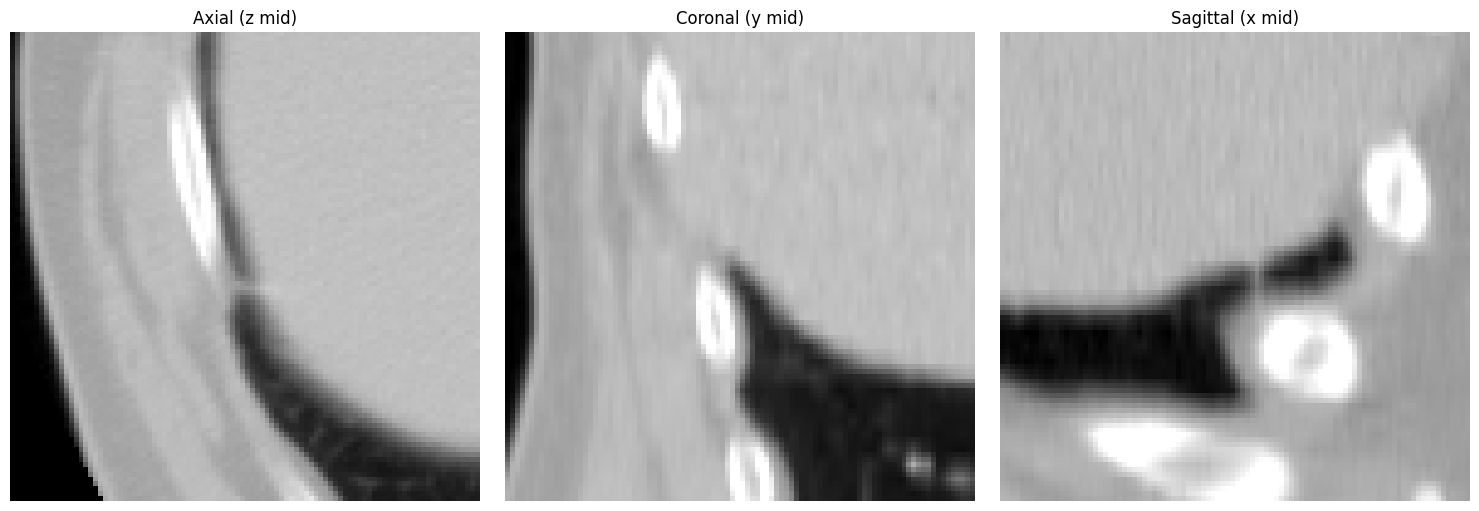

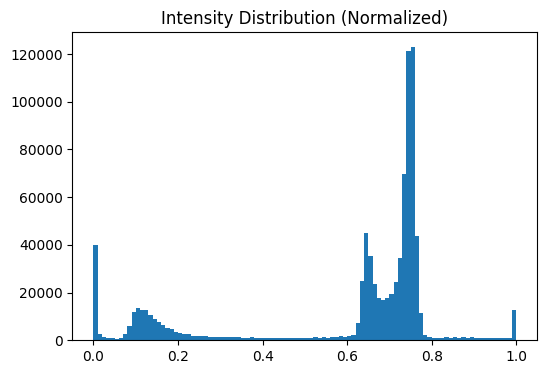

In [27]:
if len(patch_files) == 0:
    print("No patch files found.")
else:
    sample_patch = patch_files[np.random.randint(0, len(patch_files))]
    data = np.load(sample_patch, allow_pickle=True)

    volume       = data["patch"]
    label        = int(data["label"])
    nodule_id    = str(data["nodule_id"])
    centroid_vox = data["centroid_vox"]

    print("Sample patch: ", sample_patch)
    print("Patch shape:  ", volume.shape)
    print("Label:        ", label)
    print("Nodule ID:    ", nodule_id)
    print("Centroid voxel:", centroid_vox)
    print("Value range:  ", float(volume.min()), "to", float(volume.max()))

    z_mid = volume.shape[0] // 2
    y_mid = volume.shape[1] // 2
    x_mid = volume.shape[2] // 2

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(volume[z_mid, :, :], cmap="gray")
    axes[0].set_title("Axial (z mid)")

    axes[1].imshow(volume[:, y_mid, :], cmap="gray")
    axes[1].set_title("Coronal (y mid)")

    axes[2].imshow(volume[:, :, x_mid], cmap="gray")
    axes[2].set_title("Sagittal (x mid)")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.hist(volume.flatten(), bins=100)
    plt.title("Intensity Distribution (Normalized)")
    plt.show()

In [28]:
# Center-region mean — should be 0.4-0.85 (soft tissue) after fixes
print("Center 10x10x10 mean:", volume[z_mid-5:z_mid+5, y_mid-5:y_mid+5, x_mid-5:x_mid+5].mean())
print("Center voxel value:  ", volume[z_mid, y_mid, x_mid])

Center 10x10x10 mean: 0.6206
Center voxel value:   0.4785


## Summary

- Random patch extraction is removed.
- Each saved patch is nodule-centred and stored as `patch`, `label`, `nodule_id`, `centroid_vox`.
- Labeling uses: `>=4` malignant, `<=2` benign, ambiguous excluded.
- Aggregation is per nodule (radiologist mean), with patient-level malignancy as any malignant nodule.